### Image Classifier

The goal is to correctly identify pictures as "dog" or "cat"

In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


I0000 00:00:1779083606.377780     838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779083606.400464     838 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779083625.367373     838 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779083638.869239     838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Splitting the pictures into 2 folders

In [3]:
# # 1. Your current path
# raw_train_path = '/workspaces/crerov-intro-machine-learning/data/raw/dogs-vs-cats/train'

# # 2. Where we want the structured data to go
# base_dir = '/workspaces/crerov-intro-machine-learning/data/processed'
# train_dir = os.path.join(base_dir, 'train')
# test_dir = os.path.join(base_dir, 'test')

# # Create the folders
# for root in [train_dir, test_dir]:
#     for cls in ['dog', 'cat']:
#         os.makedirs(os.path.join(root, cls), exist_ok=True)

# # 3. Sort and Move the files (80% train, 20% test)
# files = [f for f in os.listdir(raw_train_path) if f.endswith('.jpg')]
# files.sort()

# for i, filename in enumerate(files):
#     # Determine class
#     category = 'dog' if filename.startswith('dog') else 'cat'
#     # Determine split
#     target_set = train_dir if i % 5 != 0 else test_dir

#     src = os.path.join(raw_train_path, filename)
#     dst = os.path.join(target_set, category, filename)
#     shutil.copy(src, dst) # Using copy instead of move to be safe

# print(f"Done! Images are now organized in {base_dir}")

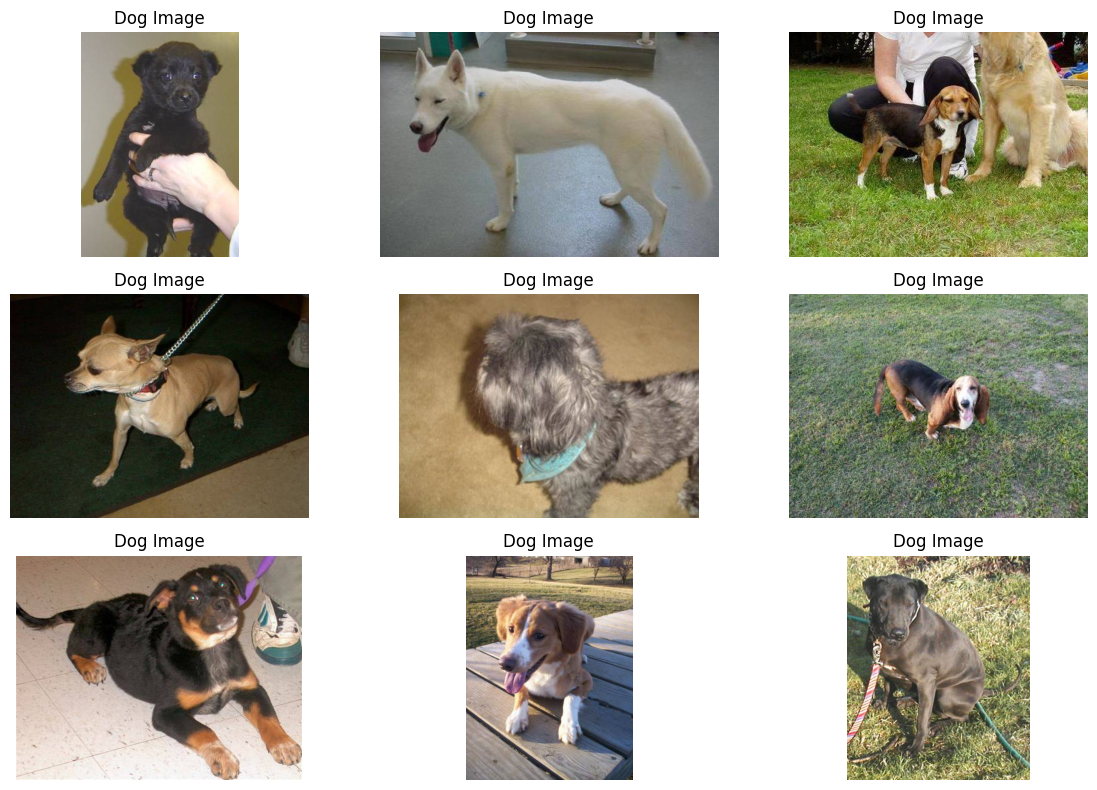

In [4]:
# Import and Check first 9 Dog Pictures

# Path to the directory containing your image data
data_dir = "/workspaces/crerov-intro-machine-learning/data/processed/cat-dog-train"

# Get a list of all dog image file names
dog_subfolder = os.path.join(data_dir, "dog")

# Get a list of all dog image file names
dog_image_files = os.listdir(dog_subfolder)

# Load the first nine dog images
dog_images = []
for i in range(9):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path)  # Adjust target_size as needed
    img_array = image.img_to_array(img)
    img_array /= 255.0  # Normalize pixel values to [0, 1]
    dog_images.append(img_array)

# Create a single figure to display all nine images
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

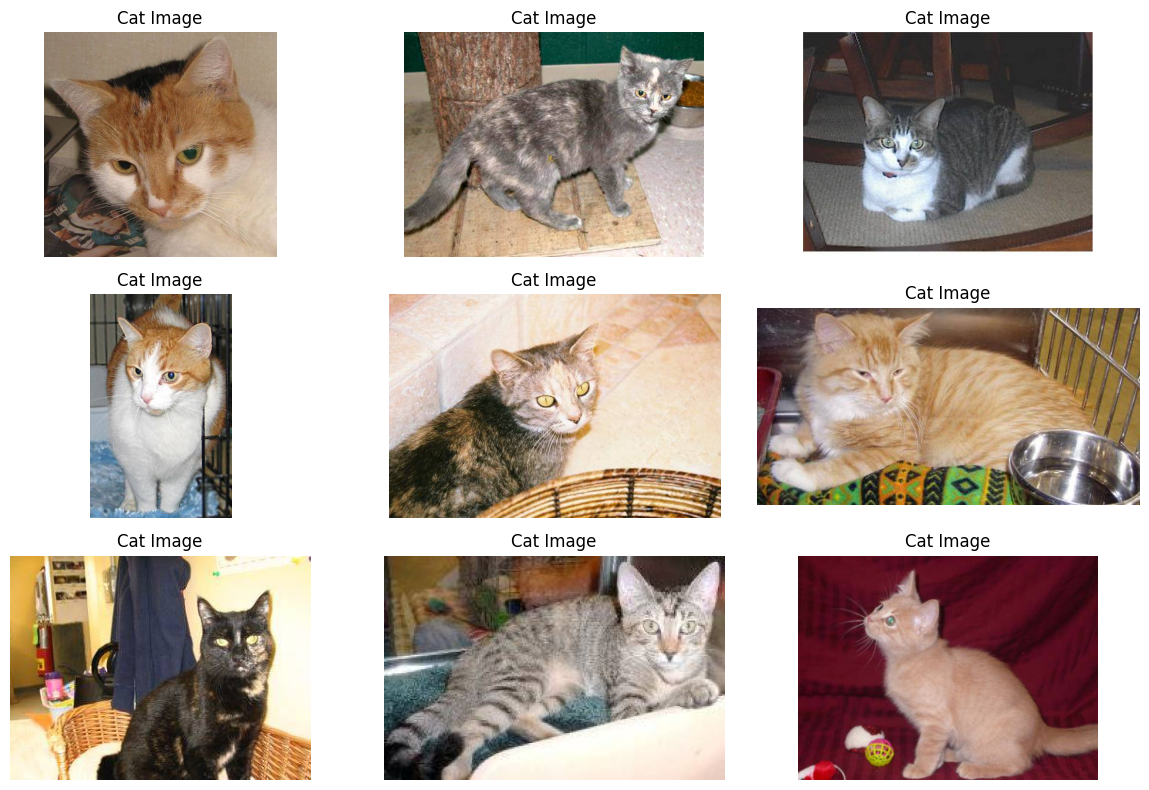

In [5]:
# Import and Check first 9 Cat Pictures

# Path to the directory containing your image data
data_dir = "/workspaces/crerov-intro-machine-learning/data/processed/cat-dog-train"

# Get a list of all cat image file names
cats_subfolder = os.path.join(data_dir, "cat")

# Get a list of all Cat image file names
cats_image_files = os.listdir(cats_subfolder)

# Load the first nine cat images
cats_images = []
for i in range(min(9, len(cats_image_files))):  # Limit to available cat images
    img_path = os.path.join(cats_subfolder, cats_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cats_images.append(img_array)

# Create a single figure to display all cat images
plt.figure(figsize=(12, 8))

for i in range(len(cats_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.title('Cat Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

### Create the images dataset

In [6]:
# 1. Path to the parent folder of 'cats' and 'dogs'
train_dir = "/workspaces/crerov-intro-machine-learning/data/processed/cat-dog-train"
image_size = (200, 200)

# 2. Add validation_split here (0.5 to get 12,500 images like the key)
trdata = ImageDataGenerator(rescale=1.0/255.0)
tsdata = ImageDataGenerator(rescale=1.0/255.0)

# 2. Pass the training folder to trdata
# This creates the 'iterator' the network will use
train_data = trdata.flow_from_directory(
    directory= "/workspaces/crerov-intro-machine-learning/data/processed/cat-dog-train", # Path to the training folder
    target_size= (200, 200),
    batch_size= 32,
    class_mode= 'categorical'
)

# 3. Pass the test (validation) folder to tsdata
test_data = tsdata.flow_from_directory(
    directory= "/workspaces/crerov-intro-machine-learning/data/processed/cat-dog-test", # Path to the test/val folder
    target_size= (200, 200),
    batch_size= 32,
    class_mode= 'categorical'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [7]:

model = Sequential([
    # Convolution Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    MaxPooling2D(2, 2),
    
    # Convolution Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Convolution Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Flatten features into a 1D vector
    Flatten(),
    
    # Hidden Dense Layer
    Dense(512, activation='relu'),
    Dropout(0.5), 
    
    # Output layer (1 neuron with sigmoid maps output to a 0-1 probability range)
    Dense(1, activation='sigmoid')
])

# Display structure overview of your network
model.summary()

/home/vscode/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779083743.453063     838 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    34,669,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,762,817 (132.61 MB)

 Trainable params: 34,762,817 (132.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train using your pre-built loaders
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5


I0000 00:00:1779083773.267573     838 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 2), output.shape=(None, 1)

NameError: name 'history' is not defined

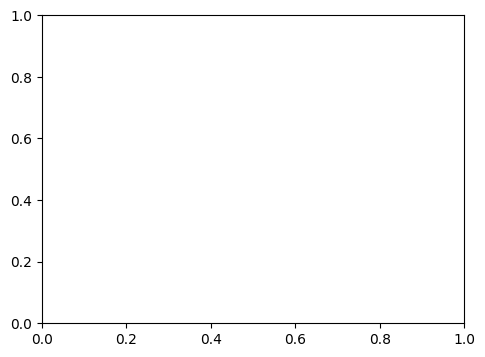

In [8]:
plt.figure(figsize=(12, 4))

# Training vs Validation Accuracy Curves
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evaluation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Training vs Validation Loss Curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evaluation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()